In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set data directory to your Drive location
os.environ["DATA_DIR"] = "/content/drive/MyDrive/UN//dataWikiArt"

Mounted at /content/drive


In [ ]:
import os
import io
import random
from pathlib import Path
import pyarrow.parquet as pq
import pyarrow as pa
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as T
from tqdm import tqdm


# ---------------- CONFIG ----------------
DATA_DIR = Path("/content/drive/MyDrive/UN/dataWikiArt").resolve() #spójna z autoencoderem

IMG_SIZE = (256, 256) # (H, W) docelowe

# Ustawienia maski (maksymalny rozmiar dziury)
MIN_HOLE = 10
MAX_HOLE_FRAC = 0.25  # max rozmiar pojedynczego kwadratu jako ułamek boku obrazu

DTYPE = np.uint8

# Wyjście
OUT_CLEAN = DATA_DIR / "clean"
OUT_DAMAGED = DATA_DIR / "damaged"
OUT_CLEAN.mkdir(exist_ok=True)
OUT_DAMAGED.mkdir(exist_ok=True)

transform = T.Resize(IMG_SIZE)
to_tensor = T.ToTensor()
# ----------------------------------------


def make_mask(shape):
    """Zwraca maskę (1, H, W) z dziurą ustawioną na 0.0 (B: 1 = normalny, 0 = dziura)."""
    _, h, w = shape
    mask = torch.ones((1, h, w), dtype=torch.float32)

    size = random.randint(MIN_HOLE, max(int(h * MAX_HOLE_FRAC), MIN_HOLE))
    top = random.randint(0, h - size)
    left = random.randint(0, w - size)
    mask[:, top:top+size, left:left+size] = 0.0
    return mask


def tensor_to_rgba_png(rgb_tensor, mask_tensor):
    """
    rgb_tensor: (3,H,W) [0,1]
    mask_tensor: (1,H,W) 0/1
    -> PNG RGBA jako bytes
    """
    rgb = rgb_tensor.numpy() * 255
    rgb = rgb.astype(np.uint8)

    alpha = (mask_tensor.numpy() * 255).astype(np.uint8)  # 0 lub 255

    rgba = np.concatenate([rgb, alpha], axis=0)  # (4,H,W)
    rgba = np.transpose(rgba, (1,2,0))  # (H,W,4)

    img = Image.fromarray(rgba, mode="RGBA")
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return buf.getvalue()


# ---------------- WCZYTANIE PLIKÓW ----------------
print("Szukam plików wejściowych...")
input_files = sorted(DATA_DIR.glob("*.parquet"))
print("Znaleziono:", len(input_files))

if not input_files:
    raise SystemExit("Brak plików parquet wejściowych!")


# schema do Parquet (jedna kolumna image)
schema = pa.schema([
    ("image", pa.struct([("bytes", pa.binary())])),
])



# ---------------- GŁÓWNA PĘTLA ----------------
for in_path in input_files:

    print("\nPrzetwarzam:", in_path.name)
    parquet_file = pq.ParquetFile(in_path)
    num_rg = parquet_file.num_row_groups

    clean_path = OUT_CLEAN / (in_path.stem + "_clean.parquet")
    damaged_path = OUT_DAMAGED / (in_path.stem + "_damaged.parquet")

    clean_writer = pq.ParquetWriter(clean_path, schema)
    damaged_writer = pq.ParquetWriter(damaged_path, schema)

    for rg in tqdm(range(num_rg), desc="row groups"):
        batch = parquet_file.read_row_group(rg).to_pylist()

        clean_rows = []
        damaged_rows = []

        for row in batch:
            img_struct = row["image"]

            # odczytaj obraz
            if isinstance(img_struct, dict) and "bytes" in img_struct:
                img = Image.open(io.BytesIO(img_struct["bytes"])).convert("RGB")
            else:
                raise ValueError("Nieoczekiwany format kolumny 'image'")

            # resize + to tensor
            img_resized = transform(img)
            img_t = to_tensor(img_resized)  # (3,H,W)

            # CLEAN (alpha = 255)
            mask_clean = torch.ones((1, *IMG_SIZE), dtype=torch.float32)
            png_clean = tensor_to_rgba_png(img_t, mask_clean)
            clean_rows.append({"bytes": png_clean})

            # DAMAGED (dziura alpha = 0)
            mask_damaged = make_mask(img_t.shape)
            png_damaged = tensor_to_rgba_png(img_t, mask_damaged)
            damaged_rows.append({"bytes": png_damaged})

        # zapisz row group
        clean_table = pa.Table.from_pylist([{"image": r} for r in clean_rows], schema=schema)
        damaged_table = pa.Table.from_pylist([{"image": r} for r in damaged_rows], schema=schema)

        clean_writer.write_table(clean_table)
        damaged_writer.write_table(damaged_table)

    clean_writer.close()
    damaged_writer.close()

    print("Zapisano pliki:")
    print("CLEAN:", clean_path)
    print("DAMAGED:", damaged_path)


print("\nGOTOWE!")

Szukam plików wejściowych...
Znaleziono: 4

Przetwarzam: train-00000-of-00007-dd79acf31a667474.parquet


row groups:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipython-input-2260588877.py:62: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgba, mode="RGBA")
row groups:   7%|▋         | 1/15 [01:31<21:26, 91.87s/it]/tmp/ipython-input-2260588877.py:62: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgba, mode="RGBA")
row groups: 100%|██████████| 15/15 [21:36<00:00, 86.46s/it]


Zapisano pliki:
CLEAN: /content/drive/MyDrive/UN/dataWikiArt/clean/train-00000-of-00007-dd79acf31a667474_clean.parquet
DAMAGED: /content/drive/MyDrive/UN/dataWikiArt/damaged/train-00000-of-00007-dd79acf31a667474_damaged.parquet

Przetwarzam: train-00001-of-00007-16d737d74ca9cb8a.parquet


row groups: 100%|██████████| 15/15 [22:42<00:00, 90.85s/it]


Zapisano pliki:
CLEAN: /content/drive/MyDrive/UN/dataWikiArt/clean/train-00001-of-00007-16d737d74ca9cb8a_clean.parquet
DAMAGED: /content/drive/MyDrive/UN/dataWikiArt/damaged/train-00001-of-00007-16d737d74ca9cb8a_damaged.parquet

Przetwarzam: train-00002-of-00007-73e15989674f270b.parquet


row groups: 100%|██████████| 15/15 [24:27<00:00, 97.86s/it]


Zapisano pliki:
CLEAN: /content/drive/MyDrive/UN/dataWikiArt/clean/train-00002-of-00007-73e15989674f270b_clean.parquet
DAMAGED: /content/drive/MyDrive/UN/dataWikiArt/damaged/train-00002-of-00007-73e15989674f270b_damaged.parquet

Przetwarzam: train-00003-of-00007-911b21abee70c83e.parquet


row groups:  40%|████      | 6/15 [12:49<18:28, 123.19s/it]

Testuję rekord indeks 7919 z 14750


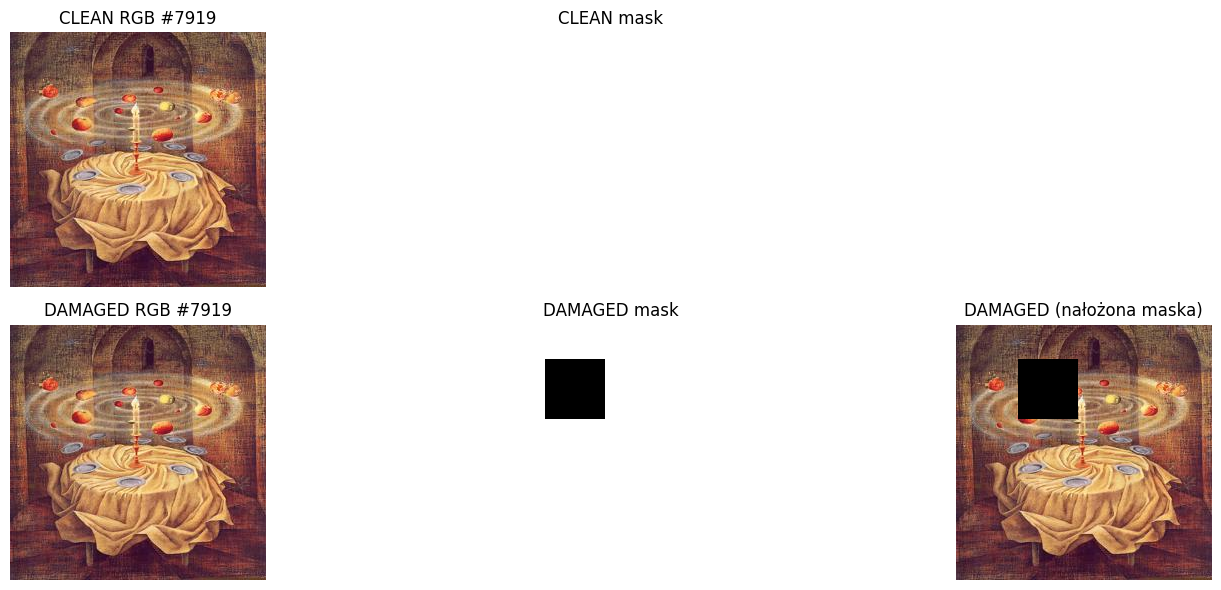

In [ ]:
import pyarrow.parquet as pq
import numpy as np
import random
import matplotlib.pyplot as plt

IMG_SIZE = (256, 256)
DTYPE = np.float32

CLEAN = "wikiart_clean_4ch.parquet"
DAMAGED = "wikiart_damaged_4ch.parquet"

def read_image_4ch_at_index(parquet_path, index):
    pf = pq.ParquetFile(parquet_path)

    # znajdź row-group i offset w row-group
    for rg in range(pf.num_row_groups):
        rg_meta = pf.metadata.row_group(rg)
        rg_rows = rg_meta.num_rows
        if index < rg_rows:
            row = pf.read_row_group(rg, columns=["image_4ch"]).to_pylist()[index]
            arr = np.frombuffer(row["image_4ch"], dtype=DTYPE)
            arr = arr.reshape((4, IMG_SIZE[0], IMG_SIZE[1]))
            rgb = np.transpose(arr[:3], (1, 2, 0))
            mask = arr[3]
            return rgb, mask
        else:
            index -= rg_rows

    raise IndexError("Index poza zakresem!")

# -------------------- LOSOWY TEST --------------------

# najpierw wyliczamy całkowitą liczbę rekordów
clean_pf = pq.ParquetFile(CLEAN)
total = sum(clean_pf.metadata.row_group(r).num_rows for r in range(clean_pf.num_row_groups))

i = random.randint(0, total - 1)
print(f"Testuję rekord indeks {i} z {total}")

clean_rgb, clean_mask = read_image_4ch_at_index(CLEAN, i)
damaged_rgb, damaged_mask = read_image_4ch_at_index(DAMAGED, i)

damaged_visual = damaged_rgb.copy()
damaged_visual[damaged_mask == 0] = 0.0  # czarna dziura

# -------------------- WYŚWIETLENIE --------------------

plt.figure(figsize=(15, 6))

plt.subplot(2, 3, 1)
plt.imshow(np.clip(clean_rgb, 0, 1))
plt.title(f"CLEAN RGB #{i}")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(clean_mask, cmap="gray", vmin=0, vmax=1)
plt.title("CLEAN mask")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(np.clip(damaged_rgb, 0, 1))
plt.title(f"DAMAGED RGB #{i}")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(damaged_mask, cmap="gray", vmin=0, vmax=1)
plt.title("DAMAGED mask")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(np.clip(damaged_visual, 0, 1))
plt.title("DAMAGED (nałożona maska)")
plt.axis("off")

plt.tight_layout()
plt.show()
